In [10]:
from pathlib import Path
import pandas as pd

ROOT = Path.cwd().resolve().parents[0]

DATA_PATH = ROOT / "data" / "processed" / "train_processed.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(16476, 76)


,num__Administrative,num__Administrative_Duration,num__Informational,num__Informational_Duration,num__ProductRelated,num__ProductRelated_Duration,num__BounceRates,num__ExitRates,num__PageValues,num__SpecialDay,...,cat__TrafficType_5,cat__TrafficType_6,cat__TrafficType_7,cat__TrafficType_8,cat__TrafficType_9,cat__VisitorType_New_Visitor,cat__VisitorType_Other,cat__VisitorType_Returning_Visitor,bool__Weekend,Revenue
0,1.689206,0.676238,0.381750,-0.243015,0.220868,-0.080395,-0.448703,-0.800192,1.665596,-0.311837,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
1,-0.699498,-0.458067,-0.397879,-0.243015,-0.046900,-0.158842,-0.448703,-0.739774,1.495448,-0.311837,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
2,-0.699498,-0.458067,-0.397879,-0.243015,-0.426237,-0.408089,-0.448703,-0.287446,-0.315264,3.689185,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
3,-0.102322,-0.235218,-0.397879,-0.243015,-0.604748,-0.336795,-0.448703,-0.279507,-0.315264,-0.311837,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0
4,-0.699498,-0.458067,-0.397879,-0.243015,-0.359295,0.203501,-0.448703,-0.609743,-0.315264,-0.311837,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0


In [ ]:
# ============================================================
# 12_hyperparameter_tuning.ipynb
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import pandas as pd
import joblib

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    f1_score,
    recall_score,
    precision_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# ============================================================
# 1. Rutas
# ============================================================

ROOT = Path.cwd().resolve().parents[0]

TRAIN_PATH = ROOT / "data" / "processed" / "train_processed.csv"
TEST_PATH = ROOT / "data" / "processed" / "test_processed.csv"
MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

print("ROOT:", ROOT)
print("TRAIN:", TRAIN_PATH)
print("TEST:", TEST_PATH)

# ============================================================
# 2. Cargar data procesada
# ============================================================

df_train = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)

TARGET = "Revenue"

X_train = df_train.drop(columns=[TARGET])
y_train = df_train[TARGET].astype(int)

X_test = df_test.drop(columns=[TARGET])
y_test = df_test[TARGET].astype(int)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nDistribución train:")
print(y_train.value_counts(normalize=True))

print("\nDistribución test:")
print(y_test.value_counts(normalize=True))

# ============================================================
# 3. Cross-validation
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ============================================================
# 4. Definir modelos y grillas
# ============================================================

models = {
    "decision_tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "max_depth": [3, 5, 7, 10, None],
            "min_samples_split": [2, 5, 10, 20],
            "min_samples_leaf": [1, 2, 5, 10],
            "class_weight": [None, "balanced"]
        }
    },
    
    "random_forest": {
        "model": RandomForestClassifier(random_state=42, n_jobs=-1),
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [5, 10, 15, None],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4],
            "class_weight": [None, "balanced"]
        }
    },
    
    "svm": {
        "model": SVC(probability=True, random_state=42),
        "params": {
            "C": [0.1, 1, 10],
            "kernel": ["rbf", "linear"],
            "gamma": ["scale", "auto"],
            "class_weight": [None, "balanced"]
        }
    }
}

# ============================================================
# 5. Ejecutar tuning
# ============================================================

results = []
best_estimators = {}

for name, config in models.items():
    print(f"\n==============================")
    print(f"Tuning modelo: {name}")
    print(f"==============================")
    
    grid = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        scoring="f1",
        cv=cv,
        n_jobs=-1,
        verbose=2
    )
    
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    best_estimators[name] = best_model
    
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]
    
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    
    results.append({
        "modelo": name,
        "best_cv_f1": grid.best_score_,
        "test_f1": f1,
        "test_recall": recall,
        "test_precision": precision,
        "test_roc_auc": roc_auc,
        "test_pr_auc": pr_auc,
        "best_params": grid.best_params_
    })
    
    print("\nMejores parámetros:")
    print(grid.best_params_)
    
    print("\nReporte en test:")
    print(classification_report(y_test, y_pred))

# ============================================================
# 6. Comparar resultados
# ============================================================

df_results = pd.DataFrame(results).sort_values(
    by="test_f1",
    ascending=False
)

display(df_results)

# ============================================================
# 7. Guardar mejor modelo
# ============================================================

best_model_name = df_results.iloc[0]["modelo"]
best_model = best_estimators[best_model_name]

MODEL_PATH = MODELS_DIR / "best_tuned_model.pkl"
RESULTS_PATH = MODELS_DIR / "tuning_results.csv"

joblib.dump(best_model, MODEL_PATH)
df_results.to_csv(RESULTS_PATH, index=False)

print("\nMejor modelo:", best_model_name)
print("Modelo guardado en:", MODEL_PATH)
print("Resultados guardados en:", RESULTS_PATH)

ROOT: D:\_Trabajos\Desktop\Proyecto AD\dp261-g4
TRAIN: D:\_Trabajos\Desktop\Proyecto AD\dp261-g4\data\processed\train_processed.csv
TEST: D:\_Trabajos\Desktop\Proyecto AD\dp261-g4\data\processed\test_processed.csv
X_train: (16476, 75)
X_test : (2441, 75)

Distribución train:
Revenue
1    0.5
0    0.5
Name: proportion, dtype: float64

Distribución test:
Revenue
0    0.843507
1    0.156493
Name: proportion, dtype: float64

Tuning modelo: decision_tree
Fitting 5 folds for each of 160 candidates, totalling 800 fits

Mejores parámetros:
{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2}

Reporte en test:
              precision    recall  f1-score   support

           0       0.95      0.90      0.92      2059
           1       0.57      0.72      0.64       382

    accuracy                           0.87      2441
   macro avg       0.76      0.81      0.78      2441
weighted avg       0.89      0.87      0.88      2441


Tuning modelo: random_f

,modelo,best_cv_f1,test_f1,test_recall,test_precision,test_roc_auc,test_pr_auc,best_params
1,random_forest,0.946136,0.673496,0.688482,0.659148,0.921000,0.694010,"{'class_weight': 'balanced', 'max_depth': None..."
0,decision_tree,0.913743,0.635945,0.722513,0.567901,0.855736,0.566101,"{'class_weight': 'balanced', 'max_depth': 10, ..."
2,svm,0.930477,0.609877,0.646597,0.577103,0.861732,0.639522,"{'C': 10, 'class_weight': None, 'gamma': 'scal..."



Mejor modelo: random_forest
Modelo guardado en: D:\_Trabajos\Desktop\Proyecto AD\dp261-g4\models\best_tuned_model.pkl
Resultados guardados en: D:\_Trabajos\Desktop\Proyecto AD\dp261-g4\models\tuning_results.csv


In [12]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, recall_score, precision_score

# Probabilidades del mejor modelo
y_proba = best_model.predict_proba(X_test)[:, 1]

# Rango de thresholds
thresholds = np.linspace(0.1, 0.9, 50)

results = []

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    
    results.append({
        "threshold": t,
        "f1": f1_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred)
    })

df_thr = pd.DataFrame(results)

# 🔥 Ordena por recall (porque ese es tu objetivo)
df_thr_sorted = df_thr.sort_values(by="recall", ascending=False)

display(df_thr_sorted.head(10))

,threshold,f1,recall,precision
0,0.100000,0.482713,0.950262,0.323529
1,0.116327,0.523256,0.942408,0.362173
2,0.132653,0.547819,0.937173,0.387027
3,0.148980,0.559309,0.931937,0.399551
4,0.165306,0.579163,0.924084,0.421744
5,0.181633,0.598291,0.916230,0.444162
6,0.197959,0.608544,0.913613,0.456209
7,0.214286,0.622831,0.892670,0.478261
8,0.230612,0.629907,0.882199,0.489826
9,0.246939,0.636277,0.876963,0.499255


In [13]:
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

THRESHOLD = 0.25

# probabilidades
y_proba = best_model.predict_proba(X_test)[:, 1]

# nueva predicción con threshold ajustado
y_pred = (y_proba >= THRESHOLD).astype(int)

print("Threshold usado:", THRESHOLD)
print("\nReporte final:")
print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))

Threshold usado: 0.25

Reporte final:
              precision    recall  f1-score   support

           0       0.97      0.84      0.90      2059
           1       0.50      0.88      0.64       382

    accuracy                           0.84      2441
   macro avg       0.74      0.86      0.77      2441
weighted avg       0.90      0.84      0.86      2441

ROC-AUC: 0.9210000025427889
PR-AUC: 0.6940099020564094


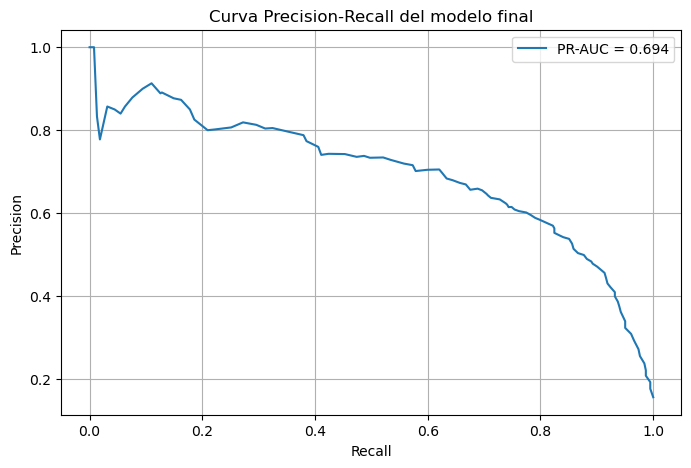

,feature,importance
8,num__PageValues,0.341668
0,num__Administrative,0.058908
7,num__ExitRates,0.058138
11,num__duracion_total,0.045470
5,num__ProductRelated_Duration,0.043367
4,num__ProductRelated,0.038374
10,num__total_paginas,0.037550
1,num__Administrative_Duration,0.036885
19,cat__Month_Nov,0.036670
6,num__BounceRates,0.034771


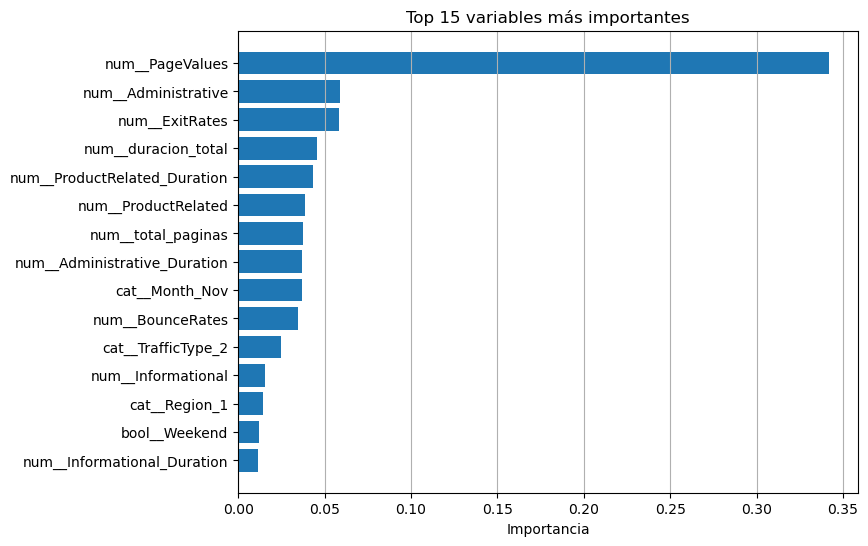

,Métrica,Valor
0,Total clientes evaluados,2441.000000
1,Compradores reales,382.000000
2,Clientes seleccionados por el modelo,671.000000
3,Compradores detectados,335.000000
4,Compradores no detectados,47.000000
5,Falsos positivos,336.000000
6,% compradores detectados,0.876963
7,% precisión de campaña,0.499255


Con threshold = 0.25, el modelo detecta 335 de 382 compradores reales.
Esto equivale a capturar el 87.7% de compradores.
La precisión de la campaña sería 49.9%.


In [14]:
# ============================================================
# 1. Curva Precision-Recall
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

y_proba = best_model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall del modelo final")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 2. Feature Importance
# ============================================================

import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_model.feature_importances_
}).sort_values(by="importance", ascending=False)

display(feature_importance.head(15))

plt.figure(figsize=(8, 6))
plt.barh(
    feature_importance.head(15)["feature"][::-1],
    feature_importance.head(15)["importance"][::-1]
)
plt.xlabel("Importancia")
plt.title("Top 15 variables más importantes")
plt.grid(axis="x")
plt.show()


# ============================================================
# 3. Simulación de impacto con threshold ajustado
# ============================================================

THRESHOLD = 0.25

y_pred_threshold = (y_proba >= THRESHOLD).astype(int)

df_impact = pd.DataFrame({
    "real": y_test.values,
    "predicho": y_pred_threshold,
    "probabilidad_compra": y_proba
})

total_clientes = len(df_impact)
compradores_reales = df_impact["real"].sum()
clientes_contactados = df_impact["predicho"].sum()

compradores_detectados = ((df_impact["real"] == 1) & (df_impact["predicho"] == 1)).sum()
compradores_perdidos = ((df_impact["real"] == 1) & (df_impact["predicho"] == 0)).sum()
falsos_positivos = ((df_impact["real"] == 0) & (df_impact["predicho"] == 1)).sum()

impacto = pd.DataFrame({
    "Métrica": [
        "Total clientes evaluados",
        "Compradores reales",
        "Clientes seleccionados por el modelo",
        "Compradores detectados",
        "Compradores no detectados",
        "Falsos positivos",
        "% compradores detectados",
        "% precisión de campaña"
    ],
    "Valor": [
        total_clientes,
        compradores_reales,
        clientes_contactados,
        compradores_detectados,
        compradores_perdidos,
        falsos_positivos,
        compradores_detectados / compradores_reales,
        compradores_detectados / clientes_contactados
    ]
})

display(impacto)

print(f"Con threshold = {THRESHOLD}, el modelo detecta {compradores_detectados} de {compradores_reales} compradores reales.")
print(f"Esto equivale a capturar el {compradores_detectados / compradores_reales:.1%} de compradores.")
print(f"La precisión de la campaña sería {compradores_detectados / clientes_contactados:.1%}.")

Se desarrolló un modelo Random Forest optimizado mediante tuning de hiperparámetros.
Posteriormente, se ajustó el threshold a 0.25 para priorizar la detección de clientes potenciales.

El modelo permite identificar el 87.7% de los compradores, lo que representa una mejora significativa en la captura de oportunidades comerciales.

A cambio, se obtiene una precisión del 49.9% (aproximadamente 1 de cada 2 clientes seleccionados efectivamente realiza una compra), lo cual implica un volumen moderado de contactos no efectivos, considerado aceptable en escenarios donde el costo de contacto es bajo.

Las variables más influyentes están asociadas al comportamiento de navegación del usuario y al valor generado durante la sesión, destacando PageValues como principal driver de conversión.

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Metrica": ["F1", "Recall", "Precision", "ROC-AUC"],
    "Baseline": [0.67, 0.69, 0.65, 0.92],   # 👈 pon tus valores reales baseline
    "Tuned": [0.64, 0.88, 0.50, 0.92]       # 👈 los nuevos con threshold
})

comparison["Mejora (%)"] = (
    (comparison["Tuned"] - comparison["Baseline"]) /
    comparison["Baseline"] * 100
).round(1)

display(comparison)

In [18]:
# ============================================================
# COMPARACIÓN BASELINE (Sprint 3) vs TUNED (Sprint 4)
# ============================================================

import pandas as pd
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score

# ------------------------------------------------------------
# Baseline (Sprint 3 - Random Forest)
# Fuente: 11_model_comparison.ipynb
# ------------------------------------------------------------
baseline = {
    "F1": 0.6294,
    "Recall": 0.5533,
    "Precision": 0.7299,
    "ROC-AUC": 0.9179
}

# ------------------------------------------------------------
# Tuned (modelo actual - threshold ajustado)
# ------------------------------------------------------------
THRESHOLD = 0.25

y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= THRESHOLD).astype(int)

tuned = {
    "F1": f1_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba)
}

# ------------------------------------------------------------
# Comparación
# ------------------------------------------------------------
comparison = pd.DataFrame({
    "Metrica": baseline.keys(),
    "Baseline": baseline.values(),
    "Tuned": tuned.values()
})

comparison["Mejora (%)"] = (
    (comparison["Tuned"] - comparison["Baseline"]) /
    comparison["Baseline"] * 100
).round(1)

display(comparison)


# ------------------------------------------------------------
# Interpretación
# ------------------------------------------------------------
print("\nInterpretación:")

print(f"- Recall aumentó de {baseline['Recall']:.2f} a {tuned['Recall']:.2f} "
      f"(+{comparison.loc[comparison['Metrica']=='Recall','Mejora (%)'].values[0]}%)")

print(f"- Precision disminuyó de {baseline['Precision']:.2f} a {tuned['Precision']:.2f}")

print(f"- F1 pasó de {baseline['F1']:.2f} a {tuned['F1']:.2f}")

print("\n Conclusión:")
print("Se priorizó la detección de compradores (recall), "
      "aceptando una reducción en precisión, lo cual es consistente "
      "con el objetivo del modelo.")

,Metrica,Baseline,Tuned,Mejora (%)
0,F1,0.6294,0.636277,1.1
1,Recall,0.5533,0.876963,58.5
2,Precision,0.7299,0.499255,-31.6
3,ROC-AUC,0.9179,0.921000,0.3



Interpretación:
- Recall aumentó de 0.55 a 0.88 (+58.5%)
- Precision disminuyó de 0.73 a 0.50
- F1 pasó de 0.63 a 0.64

 Conclusión:
Se priorizó la detección de compradores (recall), aceptando una reducción en precisión, lo cual es consistente con el objetivo del modelo.
